# Student Habits CSE 4095 Assignment

# Part 1 — Start a Google Colab Notebook

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('class1_student_habits.csv')
df.head()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,quiz_average,exam_score
0,S001,1.3,7.7,71.8,8,Strong,No,0,67.0,64.6
1,S002,9.4,6.6,74.2,14,NaN,Yes,52,74.8,81.5
2,S003,11.2,6.1,70.3,15,Some,No,7,99.1,92.0
3,S004,10.8,7.6,77.1,16,Strong,No,12,86.4,100.0
4,S005,8.0,5.6,89.7,15,NaN,Yes,12,75.7,68.5


A Pandas DataFrame is a two-dimensional table for storing and analyzing data. It has rows (observations) and named columns (variables).

In this dataset, one row represents one student and that student's study habits and assessment results. One column represents one measured characteristic, such as weekly study hours, attendance rate, or exam score.

# Part 2 — Inspect the Dataset

In [16]:
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Rows and columns: (250, 10)

Column names:
['student_id', 'study_hours_per_week', 'sleep_hours_per_night', 'attendance_rate', 'practice_problems_per_week', 'prior_programming_experience', 'study_group', 'commute_minutes', 'quiz_average', 'exam_score']

Data types:
student_id                       object
study_hours_per_week            float64
sleep_hours_per_night           float64
attendance_rate                 float64
practice_problems_per_week        int64
prior_programming_experience     object
study_group                      object
commute_minutes                   int64
quiz_average                    float64
exam_score                      float64
dtype: object

Missing values per column:
student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience    95
study_group                      0
commute_minutes                  0
quiz_average 

**Column categories**

- Numerical columns: `study_hours_per_week`, `sleep_hours_per_night`, `attendance_rate`, `practice_problems_per_week`, `commute_minutes`, `quiz_average`, and `exam_score`.
- Categorical columns: `prior_programming_experience` (the supplied file's name for prior experience) and `study_group`.
- Identifier column: `student_id`.
- Columns containing missing values in this file: `study_hours_per_week`, `sleep_hours_per_night`, and `prior_programming_experience`.

Rows with missing values are **not being deleted**. Pandas summary and grouping methods automatically exclude missing values only from the particular calculation where needed.

# Part 3 — Descriptive Statistics

In [17]:
numeric_columns = ['study_hours_per_week', 'sleep_hours_per_night', 'attendance_rate',
                   'practice_problems_per_week', 'commute_minutes', 'quiz_average', 'exam_score']

summary = df[numeric_columns].describe().T
summary['median'] = df[numeric_columns].median()
summary = summary[['count', 'mean', 'median', 'std', 'min', 'max']]
summary.round(2)

,count,mean,median,std,min,max
study_hours_per_week,241.0,7.50,7.50,2.94,0.3,17.8
sleep_hours_per_night,238.0,7.00,7.10,1.04,4.3,10.0
attendance_rate,250.0,85.47,85.75,9.58,54.4,100.0
practice_problems_per_week,250.0,16.86,16.00,9.56,0.0,78.0
commute_minutes,250.0,24.43,23.00,18.11,0.0,145.0
quiz_average,250.0,77.77,77.10,10.52,49.3,100.0
exam_score,250.0,77.16,76.95,10.33,51.4,100.0


**Three observations**

1. Commute time shows the largest relative spread of any variable, spanning from 0 to 145 minutes. Travel times differ significantly across the class. Most students likely have short commutes, while a small group faces exceptionally long travel times.
2. Quiz and exam scores show nearly identical averages and levels of spread across the class. And attendance rates are much higher and grouped more closely together. This suggests that while most students reliably attend class, their performance on assessments varies far more widely.
3. Unlike other habits, nightly sleep is highly consistent among students, averaging around 7 hours with a very small standard deviation. The close match between the mean and median further confirms this narrow spread. Consequently, sleep habits are much more uniform across the class than practice habits or commute times.


# Part 4 — Filtering, Sorting, and Grouping

In [18]:
high_effort_students = df[(df['study_hours_per_week'] >= 10) & (df['attendance_rate'] >= 90)]
high_effort_students[['student_id', 'study_hours_per_week', 'attendance_rate', 'quiz_average', 'exam_score']]

,student_id,study_hours_per_week,attendance_rate,quiz_average,exam_score
9,S010,11.7,91.0,66.2,70.5
10,S011,11.1,94.5,76.3,75.9
22,S023,10.5,93.6,81.3,79.9
41,S042,10.7,98.2,100.0,96.2
54,S055,11.4,100.0,77.1,77.1
63,S064,11.7,94.6,93.7,94.1
108,S109,10.1,91.6,94.1,100.0
119,S120,11.0,90.7,95.0,98.8
167,S168,11.8,100.0,98.3,97.2
168,S169,12.3,93.2,94.1,96.8


In [19]:
top_10 = df.nlargest(10, 'exam_score')
top_10[['student_id', 'exam_score', 'quiz_average', 'study_hours_per_week',
        'attendance_rate', 'practice_problems_per_week']]

,student_id,exam_score,quiz_average,study_hours_per_week,attendance_rate,practice_problems_per_week
3,S004,100.0,86.4,10.8,77.1,16
108,S109,100.0,94.1,10.1,91.6,25
223,S224,100.0,83.4,16.2,84.7,13
215,S216,99.0,96.4,9.0,100.0,15
119,S120,98.8,95.0,11.0,90.7,8
143,S144,97.5,88.1,9.1,96.6,16
167,S168,97.2,98.3,11.8,100.0,19
168,S169,96.8,94.1,12.3,93.2,21
139,S140,96.6,92.3,7.3,100.0,31
231,S232,96.5,84.5,5.1,93.4,15


In [20]:
study_group_summary = df.groupby('study_group')['exam_score'].agg(
    student_count='count', mean_exam_score='mean', median_exam_score='median'
).round(2)
study_group_summary

,student_count,mean_exam_score,median_exam_score
study_group,,,
No,121,76.87,75.9
Yes,129,77.43,77.7


Students in a study group (n = 129) had a slightly higher mean exam score (77.43) than students who did not (n = 121), whose mean was 76.87. The median scores show a similar pattern, with study-group participants at 77.7 compared to 75.9 for non-participants. Exam scores in the two groups were similar, with study-group participants tending to score marginally higher on both measures. The difference is small enough that it may simply reflect normal variation between two groups of this size rather than a meaningful gap. This comparison doesn't account for other factors, such as study hours, attendance, or prior experience, that could be associated with both study-group participation and exam performance. So while participation is associated with a modest edge here, this data doesn't support any claim that joining a study group caused the difference.

# Part 5 — Visualize the Data

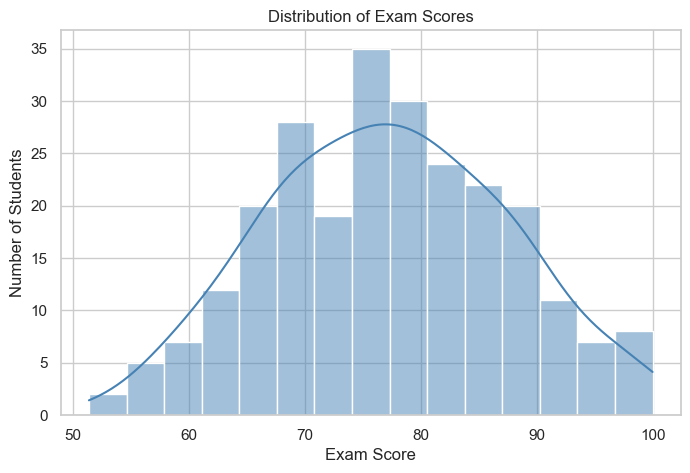

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='exam_score', bins=15, kde=True, color='steelblue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

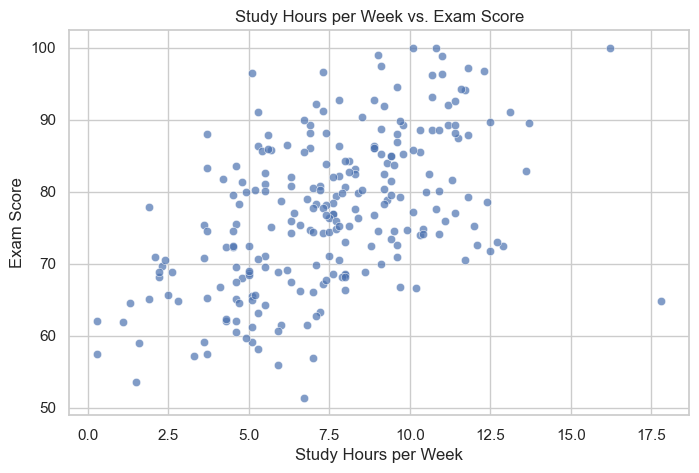

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours_per_week', y='exam_score', alpha=0.7)
plt.title('Study Hours per Week vs. Exam Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Exam Score')
plt.show()

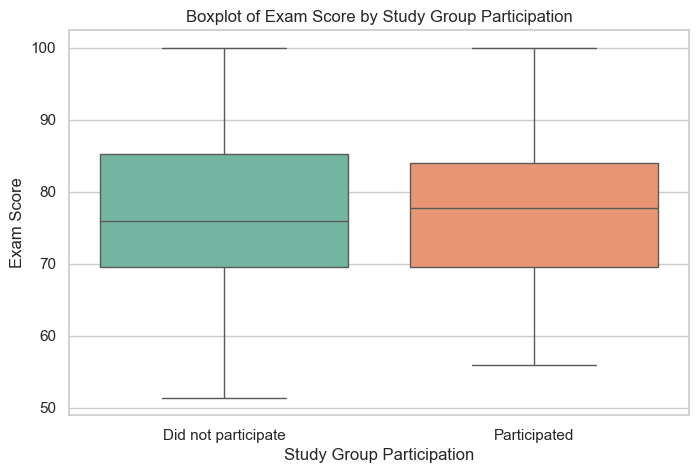

In [ ]:
# Question: Does the distribution of exam scores differ between students who participated in a study group and those who didn't?
plot_df = df.assign(study_group_participation=df['study_group'].map({'Yes': 'Participated', 'No': 'Did not participate'}))
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='study_group_participation', y='exam_score', hue='study_group_participation', legend=False, palette='Set2')
plt.title('Boxplot of Exam Score by Study Group Participation')
plt.xlabel('Study Group Participation')
plt.ylabel('Exam Score')
plt.show()

**Histogram interpretation:** Most exam scores fall between roughly 65 and 90, with a peak around 75–80 where the largest number of students scored. Scores span a wide range overall, from about 50 to 100, but the bars thin out noticeably at both ends of that range. There don't appear to be any extreme outliers separated from the rest of the data. The shape is roughly bell-shaped. 

**Study-hours scatter-plot interpretation:** The plot shows a general upward trend, as study hours per week increase, exam scores also tend to be higher on average. There's considerable scatter around this trend; at almost any given number of study hours, exam scores range widely, from the 60s up to nearly 100, so study hours alone don't predict a student's score. A couple of points stand out as unusual, including one student who studied around 18 hours per week but scored only about 65. The pattern suggests study hours are associated with somewhat higher exam scores.

**Study-group boxplot interpretation:** Students who participated in a study group had a slightly higher median exam score (around 78) compared to those who did not participate (around 76), though the two boxes overlap substantially. The middle 50% of scores (the boxes) cover a similar range for both groups, roughly 70 to 84–85, suggesting comparable overall spread. The main visible difference is at the lower end; the "did not participate" group has a lower minimum score (around 51) than the "participated" group (around 56), meaning the lowest-scoring students in this dataset were in the non-participating group.

# Part 6 — Investigate a Relationship

I expect attendance rate to be associated with exam score because students who attend class more consistently likely have more exposure to the material being tested, which may be reflected in their performance, though this doesn't necessarily mean higher attendance causes higher scores.

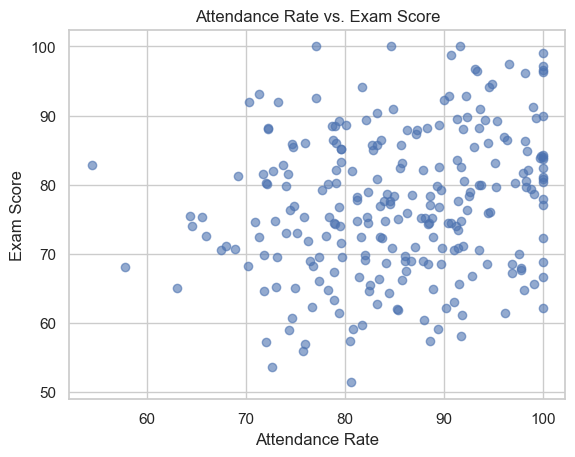

Pearson correlation between attendance_rate and exam_score: 0.2139648817527817


In [26]:
corr_data = df[['attendance_rate', 'exam_score']].dropna()

plt.scatter(corr_data['attendance_rate'], corr_data['exam_score'], alpha=0.6)

plt.title('Attendance Rate vs. Exam Score')
plt.xlabel('Attendance Rate')
plt.ylabel('Exam Score')

plt.show()

pearson_corr = corr_data['attendance_rate'].corr(corr_data['exam_score'])

print("Pearson correlation between attendance_rate and exam_score:", pearson_corr)

The Pearson correlation of 0.21 indicates a positive relationship between attendance rate and exam score. Students with higher attendance tend to have somewhat higher exam scores, on average. However, at 0.21, this relationship is weak; the scatter plot backs this up, showing a huge amount of spread at every attendance level, including some students with near-100% attendance scoring in the 60s, and one student with only about 55% attendance scoring above 80. This suggests attendance has only a modest association with exam performance in this dataset, knowing a student's attendance rate tells you very little on its own about how well they'll score. This result does not establish causation.

# Part 7 — Ask Your Own Data Question

Do students with prior programming experience tend to achieve higher exam scores than those without?

                              count       mean  median
prior_programming_experience                          
Some                            107  77.876636    78.3
Strong                           48  81.293750    83.2


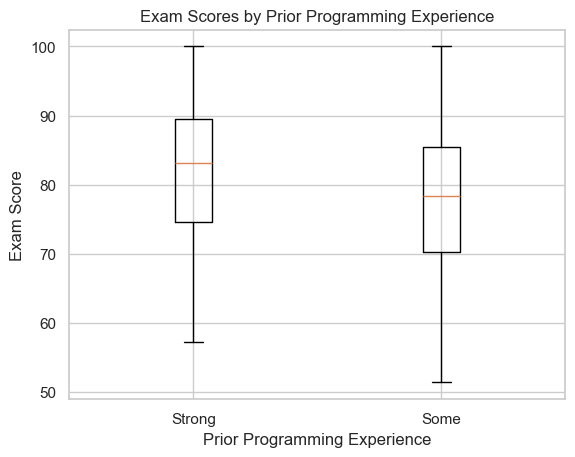

In [28]:
experience_data = df[['prior_programming_experience', 'exam_score']].dropna()

experience_summary = experience_data.groupby('prior_programming_experience')['exam_score'].agg(['count', 'mean', 'median'])

print(experience_summary)

groups = experience_data['prior_programming_experience'].unique()

data_to_plot = [experience_data[experience_data['prior_programming_experience'] == group]['exam_score'] for group in groups]

plt.boxplot(data_to_plot, tick_labels=groups)

plt.title('Exam Scores by Prior Programming Experience')
plt.xlabel('Prior Programming Experience')
plt.ylabel('Exam Score')

plt.show()

Among students with data available for this comparison, those with "Strong" prior programming experience had a higher median exam score (around 83) than those with "Some" experience (around 78). The "Strong" group's scores were also concentrated in a somewhat higher range overall, its box (middle 50% of scores) spans roughly 75–90, compared to roughly 70–85 for the "Some" group, though the two boxes overlap considerably, and both groups include students scoring as low as the mid-50s and as high as 100. This suggests prior programming experience is associated with somewhat higher exam scores in this dataset, with students reporting stronger experience tending to score a bit higher on average. 

# Part 8 — AI Reflection

Throughout this assignment, I used AI mainly to learn Pandas and Matplotlib commands I hadn't worked with before, like `groupby()`, Boolean filtering with `&`, and `sort_values()`/`nlargest()`, and to get beginner-friendly explanations of what each line of code was actually doing rather than just copying it blindly. One situation where this really helped was when I needed to filter my dataset for students meeting two conditions at once (study hours ≥ 10 and attendance ≥ 90). I hadn't worked with combining conditions in Pandas before, and the AI explained why `&` is needed instead of Python's regular `and`, and why each condition needs its own parentheses. To verify this actually worked the way I expected, I ran the code and manually spot-checked a few of the resulting students against the original DataFrame to confirm they really did meet both conditions, and I also checked that the row count made sense given how strict the filter was.

I also used AI to help me understand my results after I ran the code myself. Before this assignment, I didn't have a strong sense of what a Pearson correlation value actually means beyond "closer to 1 is more related." I learned that a correlation like 0.21 is still technically positive but weak, and that it's easy to misread a small positive number as evidence of a real, meaningful relationship when the scatter plot might show a lot of scatter instead. I made sure to check that my written interpretations actually matched what I could see in my plots and summary tables.